<h1><b>МОДЕЛИРОВАНИЕ ИДЕАЛЬНОГО ГАЗА</b></h1>

Частицы газа моделируются шариками конечного размера, которые упруго сталкиваются друг с другом. Столкновение моделируется как обмен нормальными составляющими скоростей двух частиц в системе отсчета, связанной с центром масс этих частиц.

In [137]:
# Ivan P. Markin, 2025
# Моделирование газа с упругими столкновениями
# particle  = [ [x, y, z], [Vx, Vy, Vz] ]
# particles = [ [particle1], [particle 2], ..., [particle 10]]

R = 0.2  # радиус частицы для столкновений

# движение частицы - ИСПРАВЛЕННАЯ ВЕРСИЯ
def move(p, dt):
    # Преобразуем в numpy массивы для корректных операций
    pos = np.array(p[0], dtype=np.float64)
    vel = np.array(p[1], dtype=np.float64)
    pos += dt * vel
    return [pos.tolist(), vel.tolist()]

# столкновение двух частиц
def particle_collision(p1, p2):
    # Преобразуем в numpy массивы
    p1_pos = np.array(p1[0], dtype=np.float64)
    p1_vel = np.array(p1[1], dtype=np.float64)
    p2_pos = np.array(p2[0], dtype=np.float64)
    p2_vel = np.array(p2[1], dtype=np.float64)
    
    # единичный вектор нормали
    r = p1_pos - p2_pos
    n = r / np.linalg.norm(r)

    # проекции скоростей на n
    V1n = np.dot(p1_vel, n)
    V2n = np.dot(p2_vel, n)

    # проекции скоростей на тангенс
    V1t = p1_vel - V1n * n
    V2t = p2_vel - V2n * n

    # обмен нормальными составляющими (упругое столкновение)
    V1n, V2n = V2n, V1n

    # конечные скорости
    p1_vel = V1t + V1n * n
    p2_vel = V2t + V2n * n

    # выталкиваем частицы, чтобы они не пересекались
    d = 2 * R - np.linalg.norm(r)
    p1_pos += 0.5 * d * n
    p2_pos -= 0.5 * d * n

    return [p1_pos.tolist(), p1_vel.tolist()], [p2_pos.tolist(), p2_vel.tolist()]

# Проверка столкновения
def check_collision(p1, p2):
    p1_pos = np.array(p1[0])
    p2_pos = np.array(p2[0])
    return np.linalg.norm(p1_pos - p2_pos) < 2 * R

# Моделирование с упругими столкновениями - ИСПРАВЛЕННАЯ ВЕРСИЯ
def Modeling(particles, dt=0.01):
    # Создаем глубокую копию, чтобы не менять исходные данные
    new_particles = particles.copy()
    
    # двигаем все частицы
    for i in range(len(new_particles)):
        new_particles[i] = move(new_particles[i], dt)

    # проверяем и обрабатываем столкновения
    for i in range(len(new_particles)):
        for j in range(i+1, len(new_particles)):
            if check_collision(new_particles[i], new_particles[j]):
                new_particles[i], new_particles[j] = particle_collision(new_particles[i], new_particles[j])

    return new_particles



<h1><b>НАБОР ДАТАСЕТА</b></h1>

Генерация 10 случайных частиц в шаре радиуса R

In [63]:
import random

def GenerateParticle(R=0.5, V=1., N=10, d_min=0.1):
    particles = np.zeros((N, 2, 3))
    for i in range(N):
        # Генерируем случайное направление
        phi = random.uniform(0, 2 * np.pi)
        costheta = random.uniform(-1, 1)
        u = random.uniform(0, 1)
        # Генерируем случайный радиус 
        r = R * (u ** (1/3))
        # Преобразуем сферические координаты в Декартовы
        theta = np.arccos(costheta)
        x = r * np.sin(theta) * np.cos(phi)
        y = r * np.sin(theta) * np.sin(phi)
        z = r * np.cos(theta)
        # Генерация случайных скоростей
        Vx = random.uniform(-V, V)
        Vy = random.uniform(-V, V)
        Vz = random.uniform(-V, V)
        # Проверка наложения с уже существующими частицами
        collision = False
        for p in particles:
            # Вычисляем расстояние между частицами
            dx = x - p[0][0]
            dy = y - p[0][1]
            dz = z - p[0][2]
            distance = np.sqrt(dx*dx + dy*dy + dz*dz)
            if distance < d_min:
                collision = True
                break
        # Если наложения нет, добавляем частицу
        if not collision:
            particles[i] = [[x, y, z], [Vx, Vy, Vz]]
            placed = True
    return particles

Функция для набора датасета

In [125]:
def CreateDataset(N, T, dt):
    Dataset = np.zeros((N, 2, 100, 2, 3))
    for i in range(N):
#        if i % 1000 == 0:
#            print(i)
        x = GenerateParticle(N=100)
        y = x.copy()
        for _ in range(T):
            y = Modeling(y, dt)

        object = np.array([x, y])
        Dataset[i] = object
    return Dataset

Визуализация частиц

In [161]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_particles(particles, scale=0.1, arrow_length=1.0, name='a'):

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Разделяем координаты и скорости
    positions = np.array([p[0] for p in particles])
    velocities = np.array([p[1] for p in particles])

    # Извлекаем координаты
    x = positions[:, 0]
    y = positions[:, 1]
    z = positions[:, 2]

    # Извлекаем компоненты скоростей
    Vx = velocities[:, 0]
    Vy = velocities[:, 1]
    Vz = velocities[:, 2]

    # Визуализируем частицы как точки
    scatter = ax.scatter(x, y, z, c='red', s=50, alpha=0.8, label='Частицы')

    # Визуализируем векторы скоростей
    quiver = ax.quiver(x, y, z,
                       Vx * scale, Vy * scale, Vz * scale,
                       color='blue', alpha=0.6,
                       arrow_length_ratio=0.1,
                       linewidth=1.5,
                       label='Векторы скорости')

    # Настройка осей и меток
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_zlabel('Z', fontsize=12)
    ax.set_title('Визуализация частиц с векторами скоростей', fontsize=14)

    # Добавляем сетку и легенду
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Настройка вида
    ax.set_box_aspect([1, 1, 1])  # Сохраняем пропорции осей

    # Автоматическое масштабирование для лучшего обзора
    max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max() / 2.0
    mid_x = (x.max()+x.min()) * 0.5
    mid_y = (y.max()+y.min()) * 0.5
    mid_z = (z.max()+z.min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.tight_layout()
    plt.savefig(name)
    plt.show()

<h1><b>ДАТАСЕТЫ</b></h1>

<b>Датасет 1.1:</b> 10.000 примеров, один шаг моделирования \
<b>Датасет 1.2:</b> 10.000 примеров, десять шагов моделирования \
<b>Датасет 1.3:</b> 10.000 примеров, сто шагов моделирования

0
1000
2000
3000
4000
5000
6000
7000
8000
9000


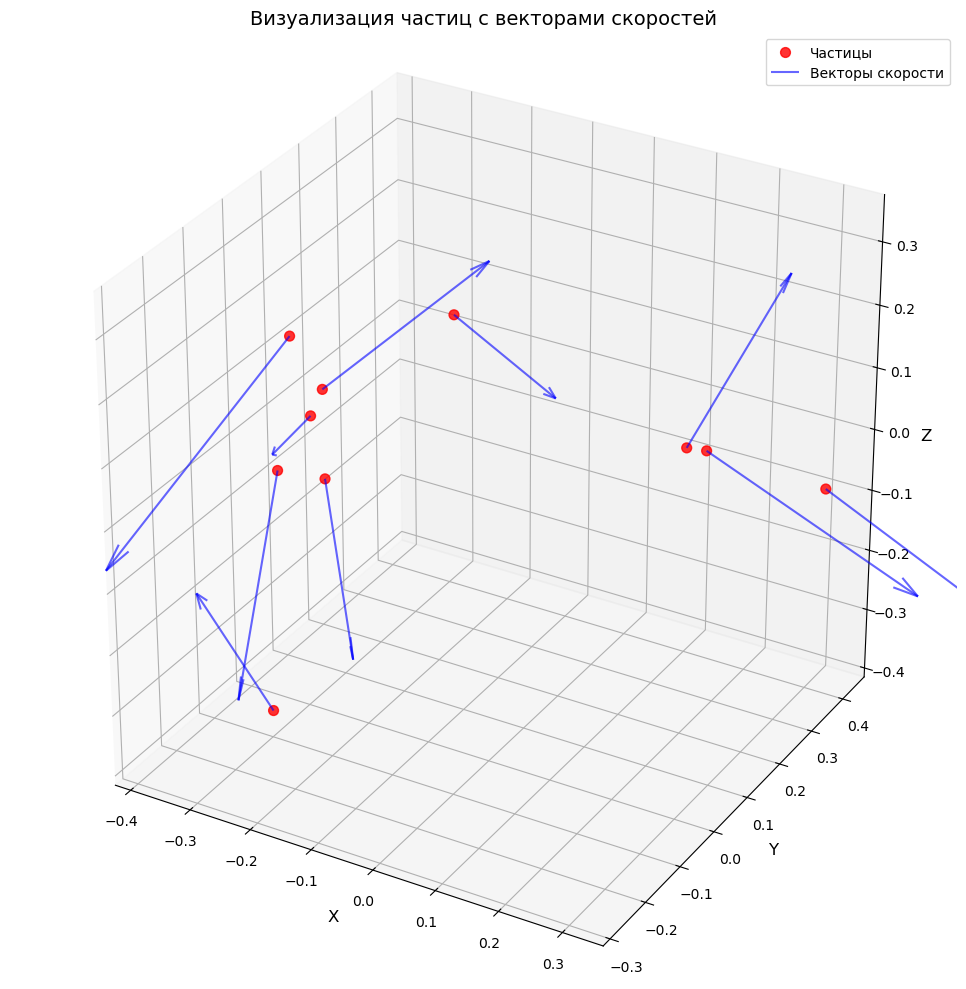

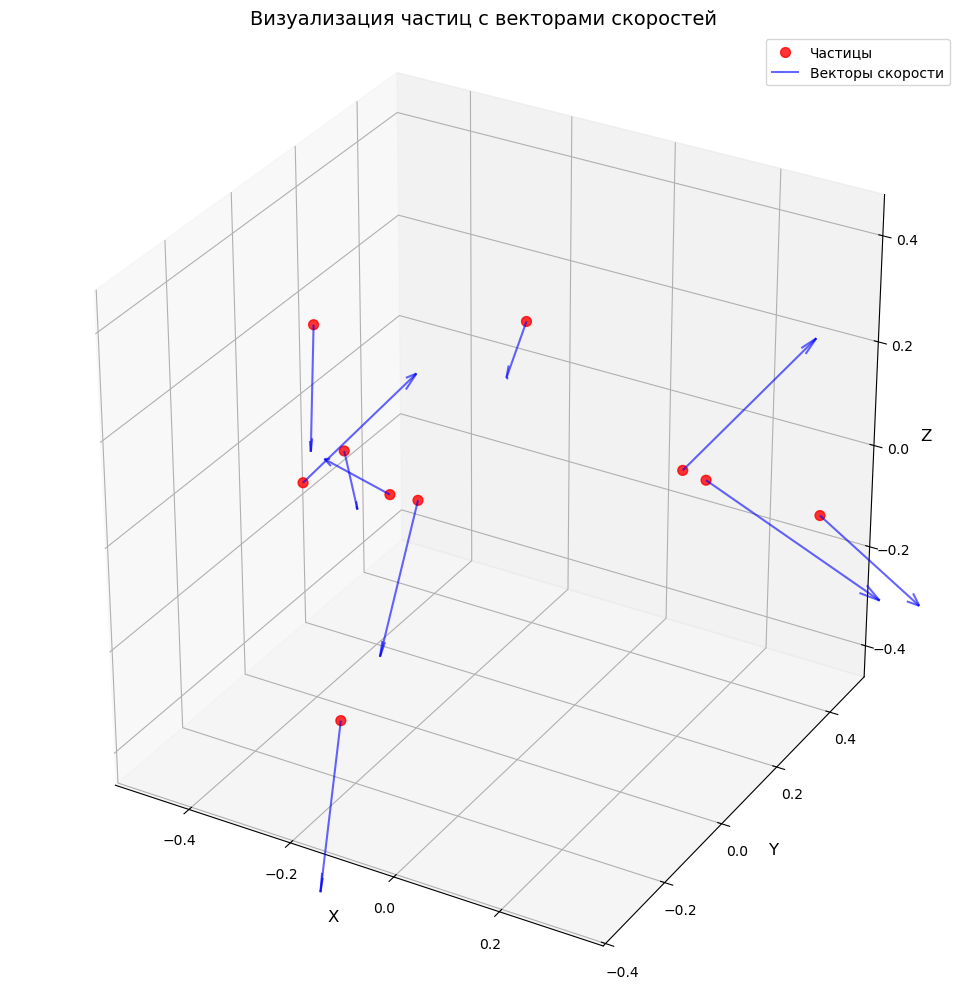

In [9]:
dataset11 = CreateDataset(10000, 1, 0.01)
visualize_particles(dataset11[5][0], scale=0.3)
visualize_particles(dataset11[5][1], scale=0.3)

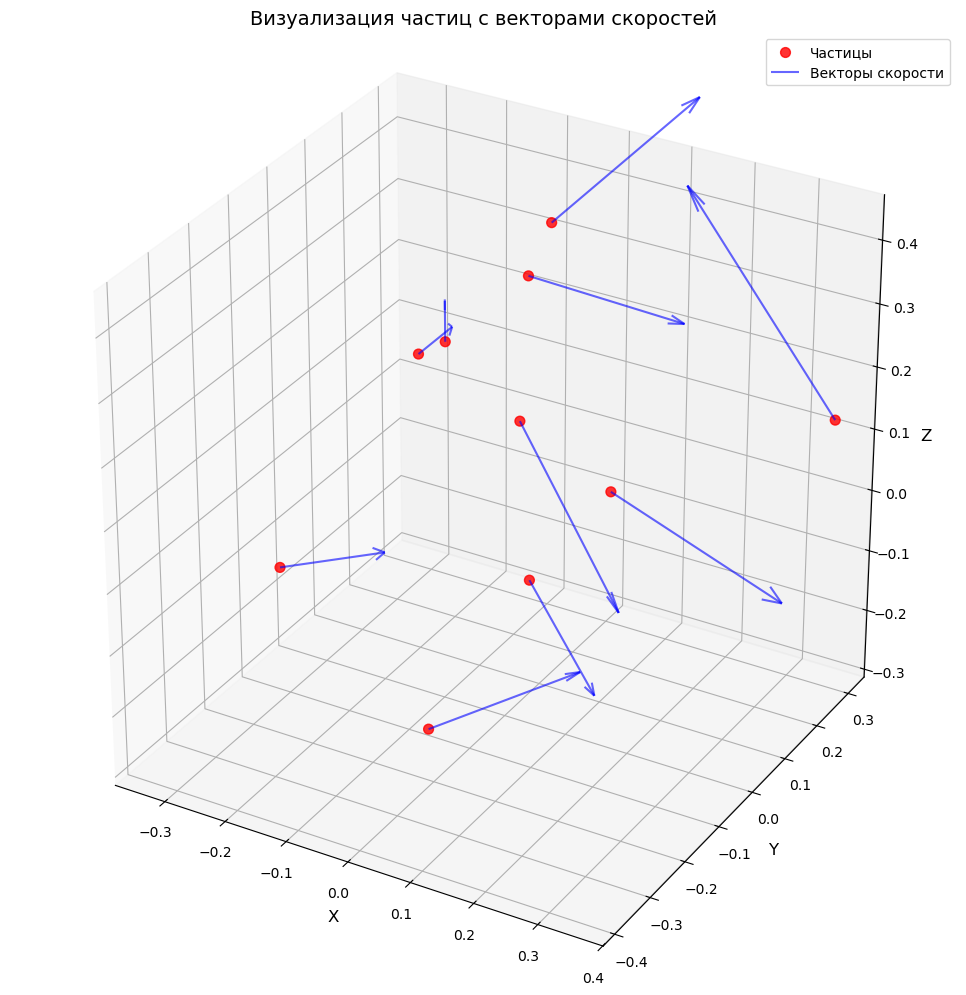

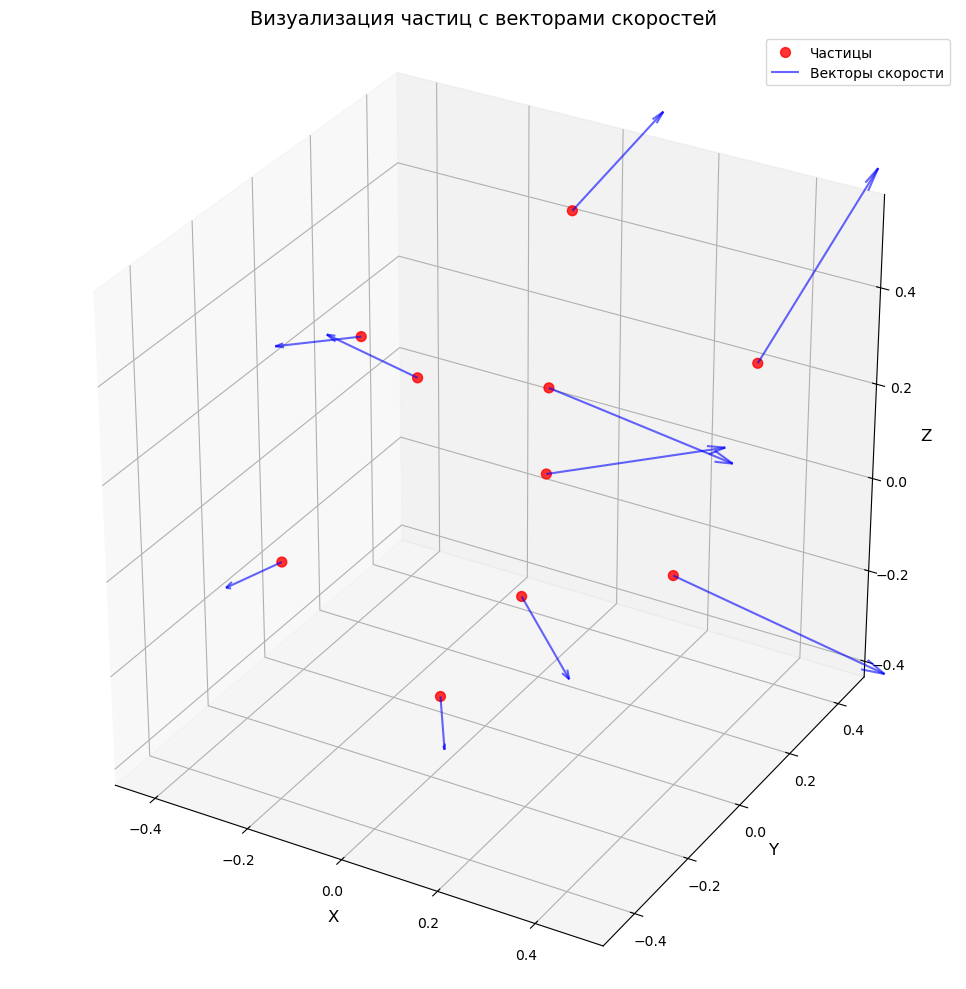

In [8]:
dataset12 = CreateDataset(10000, 10, 0.01)
visualize_particles(dataset12[0][0], scale=0.3)
visualize_particles(dataset12[0][1], scale=0.3)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000
151000
152000
153000
154000
155000
156000
157000
158000


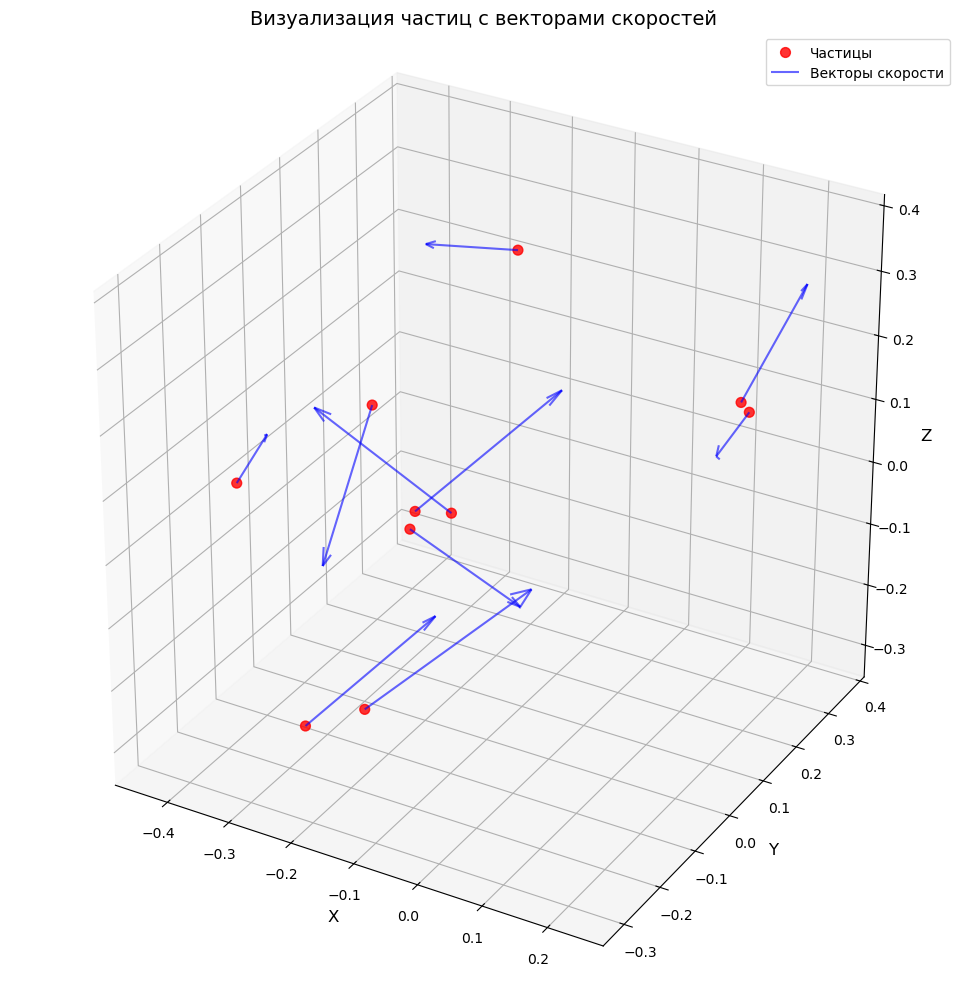

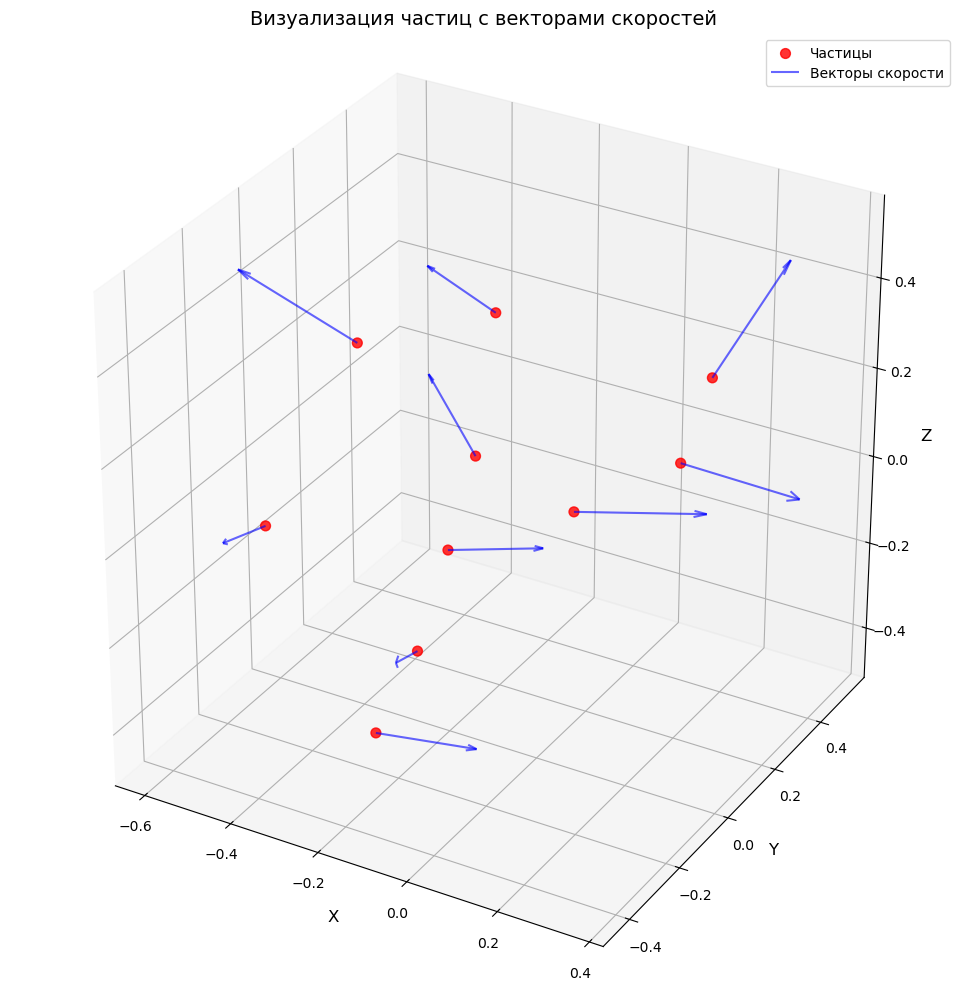

In [10]:
dataset13 = CreateDataset(1000000, 10, 0.01)
visualize_particles(dataset13[0][0], scale=0.3)
visualize_particles(dataset13[0][1], scale=0.3)

In [11]:
def prepare_data(data_tensor):
    X = data_tensor[:, 0, :, :, :]
    y = data_tensor[:, 1, :, :, :]

    X_flat = X.reshape(X.shape[0], -1)
    y_flat = y.reshape(y.shape[0], -1)

    return X_flat, y_flat

==========================================================================================

<h1><b>ПРОСТЫЕ МОДЕЛИ</b></h1>

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Модель
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 60)
        )

    def forward(self, x):
        return self.layers(x)

# Инициализация
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Функция обучения
def train_model(model, train_loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Печать
        if (epoch + 1) % 1 == 0:
            avg_loss = total_loss / len(train_loader)
            print(f"Эпоха {epoch+1:3d}, Loss: {avg_loss:.6f}")

    return model


if __name__ == "__main__":
    train_data_, train_targets_ = prepare_data(dataset11)
    train_data = torch.from_numpy(train_data_[:9990]).float()
    val_data = torch.from_numpy(train_data_[9991:]).float()
    train_targets = torch.from_numpy(train_targets_[:9990]).float()
    val_targets = torch.from_numpy(train_targets_[9991:]).float()

    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Обучаем модель
    trained_model = train_model(model, train_loader, epochs=100)

Эпоха   1, Loss: 0.160463
Эпоха   2, Loss: 0.141556
Эпоха   3, Loss: 0.137576
Эпоха   4, Loss: 0.133862
Эпоха   5, Loss: 0.130152
Эпоха   6, Loss: 0.126082
Эпоха   7, Loss: 0.121795
Эпоха   8, Loss: 0.117052
Эпоха   9, Loss: 0.111646
Эпоха  10, Loss: 0.105976
Эпоха  11, Loss: 0.099973
Эпоха  12, Loss: 0.093594
Эпоха  13, Loss: 0.087574
Эпоха  14, Loss: 0.081543
Эпоха  15, Loss: 0.076002
Эпоха  16, Loss: 0.070781
Эпоха  17, Loss: 0.065666
Эпоха  18, Loss: 0.061170
Эпоха  19, Loss: 0.057083
Эпоха  20, Loss: 0.053354
Эпоха  21, Loss: 0.050292
Эпоха  22, Loss: 0.047395
Эпоха  23, Loss: 0.044487
Эпоха  24, Loss: 0.042303
Эпоха  25, Loss: 0.040154
Эпоха  26, Loss: 0.038194
Эпоха  27, Loss: 0.036319
Эпоха  28, Loss: 0.034994
Эпоха  29, Loss: 0.033667
Эпоха  30, Loss: 0.032506
Эпоха  31, Loss: 0.031332
Эпоха  32, Loss: 0.030519
Эпоха  33, Loss: 0.029793
Эпоха  34, Loss: 0.028786
Эпоха  35, Loss: 0.027919
Эпоха  36, Loss: 0.027231
Эпоха  37, Loss: 0.026884
Эпоха  38, Loss: 0.026439
Эпоха  39, L

In [11]:
with torch.no_grad():
        prediction = trained_model(val_data[3])
        print(f"\nТестовый вход: {val_data[3]}")
        print(f"Предсказание: {prediction}")
        print(f"Реальность: {val_targets[3]}")
        print(f"Ошибка: {prediction - val_targets[3]}")


Тестовый вход: tensor([ 0.2687,  0.3412, -0.0316,  0.3360,  0.2145,  0.5423,  0.3280,  0.3332,
        -0.1546, -0.3232, -0.3431,  0.2271,  0.0450,  0.4315,  0.0558, -0.1809,
         0.0847, -0.8834,  0.3329,  0.2128,  0.0562, -0.2783,  0.1837, -0.6264,
         0.2598,  0.0241, -0.1889, -0.5930, -0.3890,  0.4482,  0.2395,  0.1479,
        -0.1316,  0.8162, -0.4500, -0.4252, -0.1523,  0.1638,  0.4455,  0.9921,
         0.8019,  0.0177,  0.2277, -0.2089, -0.3737, -0.4412, -0.7598, -0.8035,
        -0.3860,  0.1753,  0.1371, -0.5098,  0.0048,  0.6907,  0.0551,  0.2306,
        -0.1363, -0.3375, -0.5758, -0.0540])
Предсказание: tensor([ 0.0535,  0.3962, -0.1265, -0.4560,  0.9794,  0.3074,  0.2086,  0.4364,
        -0.1353, -0.2189, -0.9690,  0.3171,  0.1392,  0.4119, -0.0294,  0.3501,
         0.3287, -1.0771,  0.3382,  0.1836, -0.1455, -0.0122, -0.5480, -0.2933,
         0.1539, -0.1207, -0.2991,  0.2189,  0.2909, -0.1602,  0.1993,  0.1541,
        -0.0949,  0.5181, -0.1580, -0.0552,  

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Модель
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 60)
        )

    def forward(self, x):
        return self.layers(x)

# Инициализация
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Функция обучения
def train_model(model, train_loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Печать
        if (epoch + 1) % 1 == 0:
            avg_loss = total_loss / len(train_loader)
            print(f"Эпоха {epoch+1:3d}, Loss: {avg_loss:.6f}")

    return model

# Основное
if __name__ == "__main__":
    train_data_, train_targets_ = prepare_data(dataset12)
    train_data = torch.from_numpy(train_data_[:9990]).float()
    val_data = torch.from_numpy(train_data_[9991:]).float()
    train_targets = torch.from_numpy(train_targets_[:9990]).float()
    val_targets = torch.from_numpy(train_targets_[9991:]).float()

    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Обучаем модель
    trained_model = train_model(model, train_loader, epochs=100)

Эпоха   1, Loss: 0.138923
Эпоха   2, Loss: 0.112735
Эпоха   3, Loss: 0.107911
Эпоха   4, Loss: 0.104610
Эпоха   5, Loss: 0.100838
Эпоха   6, Loss: 0.097866
Эпоха   7, Loss: 0.095073
Эпоха   8, Loss: 0.091559
Эпоха   9, Loss: 0.088297
Эпоха  10, Loss: 0.084644
Эпоха  11, Loss: 0.080944
Эпоха  12, Loss: 0.077316
Эпоха  13, Loss: 0.073372
Эпоха  14, Loss: 0.069686
Эпоха  15, Loss: 0.065792
Эпоха  16, Loss: 0.061947
Эпоха  17, Loss: 0.058520
Эпоха  18, Loss: 0.055288
Эпоха  19, Loss: 0.052129
Эпоха  20, Loss: 0.048882
Эпоха  21, Loss: 0.046537
Эпоха  22, Loss: 0.043938
Эпоха  23, Loss: 0.041466
Эпоха  24, Loss: 0.039415
Эпоха  25, Loss: 0.037431
Эпоха  26, Loss: 0.035697
Эпоха  27, Loss: 0.034084
Эпоха  28, Loss: 0.032769
Эпоха  29, Loss: 0.031546
Эпоха  30, Loss: 0.030180
Эпоха  31, Loss: 0.029011
Эпоха  32, Loss: 0.028349
Эпоха  33, Loss: 0.027373
Эпоха  34, Loss: 0.026440
Эпоха  35, Loss: 0.025838
Эпоха  36, Loss: 0.025184
Эпоха  37, Loss: 0.024646
Эпоха  38, Loss: 0.024085
Эпоха  39, L

In [ ]:
with torch.no_grad():
        prediction = trained_model(val_data[3])
        print(f"\nТестовый вход: {val_data[3]}")
        print(f"Предсказание: {prediction}")
        print(f"Реальность: {val_targets[3]}")
        print(f"Ошибка: {prediction - val_targets[3]}")


Тестовый вход: tensor([ 0.1813, -0.2757, -0.1811, -0.1848, -0.1644,  0.3437,  0.1940, -0.2821,
         0.0480, -0.6129,  0.8056,  0.1928, -0.3023,  0.1349, -0.1463, -0.9889,
         0.0786, -0.0581, -0.4021,  0.0627, -0.1775, -0.0373,  0.7440, -0.3916,
        -0.0315,  0.0358, -0.3360, -0.1859,  0.5635,  0.8685, -0.2093, -0.0930,
         0.0368, -0.9936,  0.0036, -0.7299, -0.3939,  0.0673,  0.0320,  0.7674,
        -0.9419, -0.3777,  0.2368, -0.1282,  0.0874,  0.9450, -0.8473, -0.7805,
         0.0360, -0.0709,  0.1641, -0.1640,  0.0339,  0.2754, -0.2097,  0.3742,
         0.0945, -0.9577, -0.0232,  0.4507])
Предсказание: tensor([ 2.8914e-01, -2.5448e-01, -2.2478e-01,  5.1294e-02, -2.1747e-01,
        -1.0309e-01,  3.2590e-01, -2.7321e-01,  8.9490e-02,  1.8132e-01,
         8.1441e-04, -2.0668e-01, -2.1144e-01,  5.5400e-02, -2.0319e-01,
        -6.5322e-01,  2.7105e-01, -3.8366e-01, -3.3704e-01,  1.2345e-01,
        -4.9467e-02, -1.0021e-01,  2.6848e-01, -2.0949e-01,  1.2611e-01,


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 60)
        )

    def forward(self, x):
        return self.layers(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()


def train_model(model, train_loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()


        if (epoch + 1) % 1 == 0:
            avg_loss = total_loss / len(train_loader)
            print(f"Эпоха {epoch+1:3d}, Loss: {avg_loss:.6f}")

    return model


if __name__ == "__main__":
    train_data_, train_targets_ = prepare_data(dataset13)
    train_data = torch.from_numpy(train_data_[:990000]).float()
    val_data = torch.from_numpy(train_data_[990001:]).float()
    train_targets = torch.from_numpy(train_targets_[:990000]).float()
    val_targets = torch.from_numpy(train_targets_[990001:]).float()

    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Обучаем модель
    trained_model = train_model(model, train_loader, epochs=100)

Эпоха   1, Loss: 0.136751
Эпоха   2, Loss: 0.126052
Эпоха   3, Loss: 0.124710
Эпоха   4, Loss: 0.123551
Эпоха   5, Loss: 0.122618
Эпоха   6, Loss: 0.121673
Эпоха   7, Loss: 0.120700
Эпоха   8, Loss: 0.119833
Эпоха   9, Loss: 0.118956
Эпоха  10, Loss: 0.118171
Эпоха  11, Loss: 0.117378
Эпоха  12, Loss: 0.116672
Эпоха  13, Loss: 0.116051
Эпоха  14, Loss: 0.115376
Эпоха  15, Loss: 0.114793
Эпоха  16, Loss: 0.114197
Эпоха  17, Loss: 0.113651
Эпоха  18, Loss: 0.113098
Эпоха  19, Loss: 0.112628
Эпоха  20, Loss: 0.112129
Эпоха  21, Loss: 0.111757
Эпоха  22, Loss: 0.111261
Эпоха  23, Loss: 0.110886
Эпоха  24, Loss: 0.110500
Эпоха  25, Loss: 0.110119
Эпоха  26, Loss: 0.109721
Эпоха  27, Loss: 0.109353
Эпоха  28, Loss: 0.109042
Эпоха  29, Loss: 0.108696
Эпоха  30, Loss: 0.108373
Эпоха  31, Loss: 0.108104
Эпоха  32, Loss: 0.107736
Эпоха  33, Loss: 0.107516
Эпоха  34, Loss: 0.107210
Эпоха  35, Loss: 0.107066
Эпоха  36, Loss: 0.106788
Эпоха  37, Loss: 0.106583
Эпоха  38, Loss: 0.106319
Эпоха  39, L

===========================================================================================================================================================================================================================================================================================================================================================================================================================================================================

In [ ]:
первый датасет 

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 60)
        )

    def forward(self, x):
        return self.layers(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()


def validate_model(model, val_loader):
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_val_loss += loss.item()

    return total_val_loss / len(val_loader)


def train_model(model, train_loader, val_loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        # Обучение
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Валидация
        val_loss = validate_model(model, val_loader)
        avg_train_loss = total_loss / len(train_loader)

        print(f"Эпоха {epoch+1:3d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return model


if __name__ == "__main__":
    train_data_, train_targets_ = prepare_data(dataset11)
    train_data = torch.from_numpy(train_data_[:9900]).float()
    val_data = torch.from_numpy(train_data_[9900:]).float()
    train_targets = torch.from_numpy(train_targets_[:9900]).float()
    val_targets = torch.from_numpy(train_targets_[9900:]).float()


    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    val_dataset = TensorDataset(val_data, val_targets)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # Обучаем модель
    trained_model = train_model(model, train_loader, val_loader, epochs=5)

Эпоха   1, Train Loss: 0.183103, Val Loss: 0.179496
Эпоха   2, Train Loss: 0.172519, Val Loss: 0.173134
Эпоха   3, Train Loss: 0.166474, Val Loss: 0.171684
Эпоха   4, Train Loss: 0.162249, Val Loss: 0.169654
Эпоха   5, Train Loss: 0.158543, Val Loss: 0.166883


In [17]:
with torch.no_grad():
        prediction = trained_model(val_data[3])
        print(f"\nТестовый вход: {val_data[3]}")
        print(f"Предсказание: {prediction}")
        print(f"Реальность: {val_targets[3]}")
        print(f"Ошибка: {prediction - val_targets[3]}")


Тестовый вход: tensor([ 0.1053, -0.2761,  0.1958,  0.0625,  0.8248, -0.1018, -0.2790,  0.2428,
        -0.2724,  0.7746,  0.9198,  0.9414, -0.2560, -0.2477,  0.0129, -0.8835,
        -0.9023, -0.5196,  0.1873, -0.0017,  0.3147,  0.2511, -0.4843, -0.8643,
        -0.2883, -0.2951,  0.1234, -0.4687, -0.1720, -0.8013, -0.0350, -0.3518,
        -0.0439,  0.5672, -0.6219, -0.7642,  0.1007, -0.1238,  0.4104,  0.2148,
        -0.2027, -0.8257, -0.0109, -0.2445,  0.4024, -0.2303,  0.6749,  0.7310,
         0.2203,  0.1476,  0.2098, -0.9171, -0.7796,  0.7783,  0.3835,  0.1512,
         0.2366, -0.2695,  0.6167, -0.0539])
Предсказание: tensor([-0.0633,  0.0079,  0.0817,  0.0821,  0.1693, -0.0262, -0.1218,  0.1058,
        -0.1142, -0.1652,  0.2128,  0.3255, -0.1656, -0.1659, -0.1625, -0.2542,
        -0.4264, -0.2096,  0.1527,  0.0286,  0.0037, -0.0517, -0.2053, -0.1686,
        -0.0125, -0.1689, -0.0648,  0.0081, -0.0289, -0.2933,  0.1117,  0.0225,
        -0.2251, -0.1580, -0.0706, -0.3200, -

In [33]:
with torch.no_grad():
        prediction = trained_model(val_data[3])
        print(f"\nТестовый вход: {val_data[3]}")
        print(f"Предсказание: {prediction}")
        print(f"Реальность: {val_targets[3]}")
        print(f"Ошибка: {prediction - val_targets[3]}")

ValueError: expected 2D or 3D input (got 1D input)

In [17]:
with torch.no_grad():
        prediction = trained_model(val_data[3])
        print(f"\nТестовый вход: {val_data[3]}")
        print(f"Предсказание: {prediction}")
        print(f"Реальность: {val_targets[3]}")
        print(f"Ошибка: {prediction - val_targets[3]}")


Тестовый вход: tensor([ 0.1053, -0.2761,  0.1958,  0.0625,  0.8248, -0.1018, -0.2790,  0.2428,
        -0.2724,  0.7746,  0.9198,  0.9414, -0.2560, -0.2477,  0.0129, -0.8835,
        -0.9023, -0.5196,  0.1873, -0.0017,  0.3147,  0.2511, -0.4843, -0.8643,
        -0.2883, -0.2951,  0.1234, -0.4687, -0.1720, -0.8013, -0.0350, -0.3518,
        -0.0439,  0.5672, -0.6219, -0.7642,  0.1007, -0.1238,  0.4104,  0.2148,
        -0.2027, -0.8257, -0.0109, -0.2445,  0.4024, -0.2303,  0.6749,  0.7310,
         0.2203,  0.1476,  0.2098, -0.9171, -0.7796,  0.7783,  0.3835,  0.1512,
         0.2366, -0.2695,  0.6167, -0.0539])
Предсказание: tensor([-0.0633,  0.0079,  0.0817,  0.0821,  0.1693, -0.0262, -0.1218,  0.1058,
        -0.1142, -0.1652,  0.2128,  0.3255, -0.1656, -0.1659, -0.1625, -0.2542,
        -0.4264, -0.2096,  0.1527,  0.0286,  0.0037, -0.0517, -0.2053, -0.1686,
        -0.0125, -0.1689, -0.0648,  0.0081, -0.0289, -0.2933,  0.1117,  0.0225,
        -0.2251, -0.1580, -0.0706, -0.3200, -

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 60)
        )

    def forward(self, x):
        return self.layers(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()


def validate_model(model, val_loader):
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_val_loss += loss.item()

    return total_val_loss / len(val_loader)


def train_model(model, train_loader, val_loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        # Обучение
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Валидация
        val_loss = validate_model(model, val_loader)
        avg_train_loss = total_loss / len(train_loader)

        print(f"Эпоха {epoch+1:3d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return model


if __name__ == "__main__":
    train_data_, train_targets_ = prepare_data(dataset13)
    train_data = torch.from_numpy(train_data_[:990000]).float()
    val_data = torch.from_numpy(train_data_[990000:]).float()
    train_targets = torch.from_numpy(train_targets_[:990000]).float()
    val_targets = torch.from_numpy(train_targets_[990000:]).float()


    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    val_dataset = TensorDataset(val_data, val_targets)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # Обучаем модель
    trained_model = train_model(model, train_loader, val_loader, epochs=100)

Эпоха   1, Train Loss: 0.122685, Val Loss: 0.118303
Эпоха   2, Train Loss: 0.117787, Val Loss: 0.116628
Эпоха   3, Train Loss: 0.116323, Val Loss: 0.115573
Эпоха   4, Train Loss: 0.115221, Val Loss: 0.114661
Эпоха   5, Train Loss: 0.114526, Val Loss: 0.114265
Эпоха   6, Train Loss: 0.114166, Val Loss: 0.113861
Эпоха   7, Train Loss: 0.113890, Val Loss: 0.113365
Эпоха   8, Train Loss: 0.113693, Val Loss: 0.113499
Эпоха   9, Train Loss: 0.113556, Val Loss: 0.113410
Эпоха  10, Train Loss: 0.113426, Val Loss: 0.113682
Эпоха  11, Train Loss: 0.113319, Val Loss: 0.113444
Эпоха  12, Train Loss: 0.113239, Val Loss: 0.113269
Эпоха  13, Train Loss: 0.113154, Val Loss: 0.113228


KeyboardInterrupt: 

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 60)
        )

    def forward(self, x):
        return self.layers(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()


def validate_model(model, val_loader):
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_val_loss += loss.item()

    return total_val_loss / len(val_loader)


def train_model(model, train_loader, val_loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        # Обучение
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Валидация
        val_loss = validate_model(model, val_loader)
        avg_train_loss = total_loss / len(train_loader)

        print(f"Эпоха {epoch+1:3d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return model


if __name__ == "__main__":
    train_data_, train_targets_ = prepare_data(dataset13)
    train_data = torch.from_numpy(train_data_[:990000]).float()
    val_data = torch.from_numpy(train_data_[990000:]).float()
    train_targets = torch.from_numpy(train_targets_[:990000]).float()
    val_targets = torch.from_numpy(train_targets_[990000:]).float()


    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

    val_dataset = TensorDataset(val_data, val_targets)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

    # Обучаем модель
    trained_model = train_model(model, train_loader, val_loader, epochs=100)

Эпоха   1, Train Loss: 0.176809, Val Loss: 0.171907
Эпоха   2, Train Loss: 0.171636, Val Loss: 0.171002
Эпоха   3, Train Loss: 0.170361, Val Loss: 0.169675
Эпоха   4, Train Loss: 0.169604, Val Loss: 0.171505
Эпоха   5, Train Loss: 0.170372, Val Loss: 0.169666
Эпоха   6, Train Loss: 0.169925, Val Loss: 0.169206
Эпоха   7, Train Loss: 0.169763, Val Loss: 0.169264
Эпоха   8, Train Loss: 0.169702, Val Loss: 0.169851
Эпоха   9, Train Loss: 0.169789, Val Loss: 0.170735
Эпоха  10, Train Loss: 0.169943, Val Loss: 0.169720
Эпоха  11, Train Loss: 0.170163, Val Loss: 0.170062
Эпоха  12, Train Loss: 0.170030, Val Loss: 0.170264
Эпоха  13, Train Loss: 0.170084, Val Loss: 0.170221
Эпоха  14, Train Loss: 0.170094, Val Loss: 0.170026


KeyboardInterrupt: 

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 60)
        )

    def forward(self, x):
        return self.layers(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()


def validate_model(model, val_loader):
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_val_loss += loss.item()

    return total_val_loss / len(val_loader)


def train_model(model, train_loader, val_loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        # Обучение
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Валидация
        val_loss = validate_model(model, val_loader)
        avg_train_loss = total_loss / len(train_loader)

        print(f"Эпоха {epoch+1:3d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return model


if __name__ == "__main__":
    train_data_, train_targets_ = prepare_data(dataset13)
    train_data = torch.from_numpy(train_data_[:990000]).float()
    val_data = torch.from_numpy(train_data_[990000:]).float()
    train_targets = torch.from_numpy(train_targets_[:990000]).float()
    val_targets = torch.from_numpy(train_targets_[990000:]).float()


    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

    val_dataset = TensorDataset(val_data, val_targets)
    val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

    # Обучаем модель
    trained_model = train_model(model, train_loader, val_loader, epochs=100)

Эпоха   1, Train Loss: 0.174684, Val Loss: 0.162749
Эпоха   2, Train Loss: 0.161017, Val Loss: 0.158890
Эпоха   3, Train Loss: 0.158005, Val Loss: 0.156832
Эпоха   4, Train Loss: 0.156172, Val Loss: 0.155115
Эпоха   5, Train Loss: 0.154082, Val Loss: 0.151967
Эпоха   6, Train Loss: 0.151887, Val Loss: 0.151236
Эпоха   7, Train Loss: 0.151095, Val Loss: 0.150607
Эпоха   8, Train Loss: 0.150423, Val Loss: 0.150280
Эпоха   9, Train Loss: 0.150039, Val Loss: 0.149973
Эпоха  10, Train Loss: 0.149750, Val Loss: 0.150265
Эпоха  11, Train Loss: 0.149384, Val Loss: 0.148993
Эпоха  12, Train Loss: 0.149249, Val Loss: 0.150059
Эпоха  13, Train Loss: 0.149038, Val Loss: 0.149300
Эпоха  14, Train Loss: 0.148869, Val Loss: 0.148705
Эпоха  15, Train Loss: 0.148648, Val Loss: 0.148651


KeyboardInterrupt: 

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


class SimpleModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 60)
        )

    def forward(self, x):
        return self.layers(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.03)
criterion = nn.MSELoss()


def validate_model(model, val_loader):
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_val_loss += loss.item()

    return total_val_loss / len(val_loader)


def train_model(model, train_loader, val_loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        # Обучение
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        val_loss = validate_model(model, val_loader)
        avg_train_loss = total_loss / len(train_loader)

        print(f"Эпоха {epoch+1:3d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return model


if __name__ == "__main__":
    train_data_, train_targets_ = prepare_data(dataset13)
    train_data = torch.from_numpy(train_data_[:990000]).float()
    val_data = torch.from_numpy(train_data_[990000:]).float()
    train_targets = torch.from_numpy(train_targets_[:990000]).float()
    val_targets = torch.from_numpy(train_targets_[990000:]).float()

    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

    val_dataset = TensorDataset(val_data, val_targets)
    val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

    # Обучаем модель
    trained_model = train_model(model, train_loader, val_loader, epochs=100)

Эпоха   1, Train Loss: 0.216315, Val Loss: 0.199988
Эпоха   2, Train Loss: 0.178108, Val Loss: 0.162666
Эпоха   3, Train Loss: 0.155287, Val Loss: 0.150231
Эпоха   4, Train Loss: 0.149772, Val Loss: 0.149717
Эпоха   5, Train Loss: 0.149462, Val Loss: 0.149146
Эпоха   6, Train Loss: 0.149230, Val Loss: 0.149009
Эпоха   7, Train Loss: 0.149042, Val Loss: 0.149843
Эпоха   8, Train Loss: 0.148784, Val Loss: 0.148847
Эпоха   9, Train Loss: 0.148334, Val Loss: 0.148115
Эпоха  10, Train Loss: 0.147919, Val Loss: 0.147916
Эпоха  11, Train Loss: 0.147581, Val Loss: 0.148300
Эпоха  12, Train Loss: 0.145596, Val Loss: 0.146045
Эпоха  13, Train Loss: 0.143550, Val Loss: 0.142482
Эпоха  14, Train Loss: 0.139042, Val Loss: 0.134832
Эпоха  15, Train Loss: 0.129030, Val Loss: 0.124649
Эпоха  16, Train Loss: 0.118471, Val Loss: 0.114579
Эпоха  17, Train Loss: 0.114287, Val Loss: 0.112747
Эпоха  18, Train Loss: 0.112322, Val Loss: 0.111467
Эпоха  19, Train Loss: 0.110624, Val Loss: 0.109796
Эпоха  20, T

KeyboardInterrupt: 

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau 


class SimpleModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 60)
        )

    def forward(self, x):
        return self.layers(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01) 
criterion = nn.MSELoss()


def validate_model(model, val_loader):
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_val_loss += loss.item()

    return total_val_loss / len(val_loader)


def train_model(model, train_loader, val_loader, epochs=10):
    model.train()

    # Расписание
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',           
        factor=0.5,           
        patience=2           
    )

    for epoch in range(epochs):
        total_loss = 0

        # Обучение
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Валидация
        val_loss = validate_model(model, val_loader)
        avg_train_loss = total_loss / len(train_loader)
        
        scheduler.step(val_loss)

        print(f"Эпоха {epoch+1:3d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return model

if __name__ == "__main__":
    train_data_, train_targets_ = prepare_data(dataset13)
    train_data = torch.from_numpy(train_data_[:990000]).float()
    val_data = torch.from_numpy(train_data_[990000:]).float()
    train_targets = torch.from_numpy(train_targets_[:990000]).float()
    val_targets = torch.from_numpy(train_targets_[990000:]).float()


    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

    val_dataset = TensorDataset(val_data, val_targets)
    val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

    # Обучаем модель
    trained_model = train_model(model, train_loader, val_loader, epochs=100)

Эпоха   1, Train Loss: 0.176079, Val Loss: 0.157301
Эпоха   2, Train Loss: 0.151487, Val Loss: 0.147409
Эпоха   3, Train Loss: 0.136249, Val Loss: 0.127462
Эпоха   4, Train Loss: 0.123309, Val Loss: 0.120876
Эпоха   5, Train Loss: 0.118900, Val Loss: 0.118778
Эпоха   6, Train Loss: 0.117915, Val Loss: 0.118440
Эпоха   7, Train Loss: 0.117642, Val Loss: 0.117362
Эпоха   8, Train Loss: 0.117355, Val Loss: 0.117367
Эпоха   9, Train Loss: 0.117083, Val Loss: 0.117409
Эпоха  10, Train Loss: 0.116726, Val Loss: 0.116988
Эпоха  11, Train Loss: 0.116245, Val Loss: 0.116309
Эпоха  12, Train Loss: 0.114750, Val Loss: 0.114040
Эпоха  13, Train Loss: 0.112661, Val Loss: 0.111453
Эпоха  14, Train Loss: 0.109917, Val Loss: 0.108521
Эпоха  15, Train Loss: 0.107778, Val Loss: 0.107139
Эпоха  16, Train Loss: 0.105593, Val Loss: 0.104516
Эпоха  17, Train Loss: 0.103500, Val Loss: 0.102796
Эпоха  18, Train Loss: 0.101702, Val Loss: 0.101026
Эпоха  19, Train Loss: 0.099919, Val Loss: 0.099625
Эпоха  20, T

In [37]:
with torch.no_grad():
        prediction = trained_model(val_data[3:5])
        print(f"\nТестовый вход: {val_data[3]}")
        print(f"Предсказание: {prediction[0]}")
        print(f"Реальность: {val_targets[3]}")
        print(f"Ошибка: {prediction[0] - val_targets[3]}")


Тестовый вход: tensor([ 0.2998,  0.0064, -0.3626, -0.3064, -0.3283,  0.4544, -0.1747,  0.2277,
         0.1546,  0.7346, -0.4294, -0.5713, -0.3944, -0.1587, -0.0903, -0.4407,
        -0.5759,  0.6678, -0.4223,  0.1699, -0.0647,  0.2332,  0.6271,  0.3125,
         0.3544, -0.0296, -0.1346, -0.0708, -0.2767, -0.7396, -0.2144,  0.0163,
        -0.2021,  0.2356, -0.1851, -0.3581, -0.1530,  0.3041,  0.3303,  0.2260,
        -0.8120,  0.6297,  0.1700,  0.1943,  0.2157,  0.0149, -0.8647, -0.0807,
         0.2528, -0.1923,  0.2632, -0.3959,  0.5173, -0.4143,  0.3536,  0.1983,
        -0.0862,  0.3231, -0.1736,  0.3670])
Предсказание: tensor([ 0.2635, -0.0209, -0.4089, -0.0389, -0.2807, -0.1357, -0.1174,  0.2787,
         0.1966,  0.3412, -0.0773,  0.0968, -0.4227, -0.2436, -0.0553, -0.4196,
        -0.5629,  0.3290, -0.4419,  0.1761, -0.0584, -0.0505,  0.3678,  0.1177,
         0.3790, -0.0823, -0.2290,  0.0668, -0.4262, -0.6317, -0.2194, -0.0504,
        -0.2795, -0.0497, -0.2410, -0.4621, -

In [ ]:
import torch
torch.save(trained_model, 'model1.pth')

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau 


class SimpleModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 60)
        )

    def forward(self, x):
        return self.layers(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01) 
criterion = nn.MSELoss()


def validate_model(model, val_loader):
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_val_loss += loss.item()

    return total_val_loss / len(val_loader)


def train_model(model, train_loader, val_loader, epochs=10):
    model.train()

    # Расписание
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',           
        factor=0.5,           
        patience=2           
    )

    for epoch in range(epochs):
        total_loss = 0

        # Обучение
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Валидация
        val_loss = validate_model(model, val_loader)
        avg_train_loss = total_loss / len(train_loader)

        if epoch % 3 == 0:
            new_lr = float(input())
            optimizer.param_groups[0]['lr'] = new_lr
        
#       scheduler.step(val_loss)

        print(f"Эпоха {epoch+1:3d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return model

if __name__ == "__main__":
    train_data_, train_targets_ = prepare_data(dataset13)
    train_data = torch.from_numpy(train_data_[:990000]).float()
    val_data = torch.from_numpy(train_data_[990000:]).float()
    train_targets = torch.from_numpy(train_targets_[:990000]).float()
    val_targets = torch.from_numpy(train_targets_[990000:]).float()


    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

    val_dataset = TensorDataset(val_data, val_targets)
    val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

    # Обучаем модель
    trained_model = train_model(model, train_loader, val_loader, epochs=100)

 0.01


Эпоха   1, Train Loss: 0.178310, Val Loss: 0.161918
Эпоха   2, Train Loss: 0.156246, Val Loss: 0.150431
Эпоха   3, Train Loss: 0.134850, Val Loss: 0.125563


 0.01


Эпоха   4, Train Loss: 0.121870, Val Loss: 0.119310
Эпоха   5, Train Loss: 0.118406, Val Loss: 0.118352
Эпоха   6, Train Loss: 0.117885, Val Loss: 0.117982


 0.005


...

 0.0026


Эпоха  52, Train Loss: 0.093665, Val Loss: 0.094136
Эпоха  53, Train Loss: 0.093644, Val Loss: 0.094065
Эпоха  54, Train Loss: 0.093460, Val Loss: 0.093859


 0.023


Эпоха  55, Train Loss: 0.093277, Val Loss: 0.093731
Эпоха  56, Train Loss: 0.192138, Val Loss: 0.181969


KeyboardInterrupt: 

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
from scipy.spatial import KDTree
from typing import Tuple, List, Optional
import warnings


class SimpleModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(SimpleModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.15),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.1),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.05),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.05),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.),
            nn.Linear(256, 60)
        )
        
    def forward(self, x):
        return self.layers(x)

class PhysicsAwareLoss(nn.Module):
    def __init__(self, alpha=0.1, beta=0.1, mse_weight=1.0, energy_weight=1.0):
        super(PhysicsAwareLoss, self).__init__()
        self.alpha = alpha  # Вес для сохранения энергии
        self.beta = beta    # Вес для сохранения импульса
        self.mse_weight = mse_weight
        self.energy_weight = energy_weight
        
    def compute_kinetic_energy(self, batch_data):
        batch_size = batch_data.shape[0]
        # Преобразуем в (batch_size, 10, 6)
        data_3d = batch_data.view(batch_size, 10, 6)
        # Скорости - последние 3 компоненты
        velocities = data_3d[:, :, 3:]  # (batch_size, 10, 3)
        # Квадраты скоростей
        v_squared = torch.sum(velocities ** 2, dim=2)  # (batch_size, 10)
        # Суммируем по всем частицам в сфере (предполагаем массу = 1)
        kinetic_energy = 0.5 * torch.sum(v_squared, dim=1)  # (batch_size,)
        return kinetic_energy
    
    def forward(self, predictions, targets, inputs=None):
        # MSE между предсказаниями и целями
        mse_loss = nn.functional.mse_loss(predictions, targets)
        
        # Если предоставлены входные данные, добавляем физические ограничения
        if inputs is not None:
            # Сохранение кинетической энергии
            kinetic_energy_pred = self.compute_kinetic_energy(predictions)
            kinetic_energy_input = self.compute_kinetic_energy(inputs)
            energy_loss = nn.functional.mse_loss(kinetic_energy_pred, kinetic_energy_input)
            
            
            # Общая функция потерь
            total_loss = (self.mse_weight * mse_loss + 
                         self.energy_weight * energy_loss)
            
            return total_loss, {
                'mse_loss': mse_loss.item(),
                'energy_loss': energy_loss.item()
            }
        else:
            return mse_loss, {'mse_loss': mse_loss.item()}

def validate_model(model, val_loader, criterion):
    model.eval()
    total_val_loss = 0
    total_mse_loss = 0
    total_energy_loss = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss, loss_dict = criterion(output, target, data)
            total_val_loss += loss.item()
            total_mse_loss += loss_dict['mse_loss']
            if 'energy_loss' in loss_dict:
                total_energy_loss += loss_dict['energy_loss']
    
    avg_val_loss = total_val_loss / len(val_loader)
    avg_mse_loss = total_mse_loss / len(val_loader)
    avg_energy_loss = total_energy_loss / len(val_loader) if total_energy_loss > 0 else 0
    
    return avg_val_loss, avg_mse_loss, avg_energy_loss


def train_model(model, train_loader, val_loader, epochs=10, 
                lr=0.001, lambda_energy=0.1, lambda_momentum=0.01):
    model.train()
    
    # Используем физически осознанную функцию потерь
    criterion = PhysicsAwareLoss(
        energy_weight=lambda_energy,
        mse_weight=1.0
    )
    
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.7,
        patience=3,
        threshold=0.007
    )
    
    for epoch in range(epochs):
        total_loss = 0
        total_mse = 0
        total_energy = 0
        
        # Обучение
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss, loss_dict = criterion(output, target, data)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_mse += loss_dict['mse_loss']
            if 'energy_loss' in loss_dict:
                total_energy += loss_dict['energy_loss']
        
        # Валидация
        val_loss, val_mse, val_energy = validate_model(model, val_loader, criterion)
        avg_train_loss = total_loss / len(train_loader)
        avg_train_mse = total_mse / len(train_loader)
        avg_train_energy = total_energy / len(train_loader) if total_energy > 0 else 0
        
        #scheduler.step(val_loss)
            
        # Вывод статистики
        print(f"Эпоха {epoch+1:3d}/{epochs}:")
        print(f"  Train: Loss={avg_train_loss:.6f}, MSE={avg_train_mse:.6f}, "
              f"Energy={avg_train_energy:.6f}")
        print(f"  Val:   Loss={val_loss:.6f}, MSE={val_mse:.6f}, "
              f"Energy={val_energy:.6f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 50)
    
    return model

if __name__ == "__main__":
    print("start")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleModel().to(device)
 
    
    train_data_, train_targets_ = prepare_data(dataset13)
    train_data = torch.from_numpy(train_data_[:990000]).float()
    val_data = torch.from_numpy(train_data_[990000:]).float()
    train_targets = torch.from_numpy(train_targets_[:990000]).float()
    val_targets = torch.from_numpy(train_targets_[990000:]).float()


    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)

    val_dataset = TensorDataset(val_data, val_targets)
    val_loader = DataLoader(val_dataset, batch_size=4096, shuffle=False)

    # Обучаем модель
    trained_model = train_model(model, train_loader, val_loader, epochs=1000, lr=0.007, lambda_energy=0.1)

start
Эпоха   1/1000:
  Train: Loss=0.437502, MSE=0.311156, Energy=1.263464
  Val:   Loss=0.298047, MSE=0.225126, Energy=0.729207
  LR: 0.000100
--------------------------------------------------
Эпоха   2/1000:
  Train: Loss=0.233149, MSE=0.196436, Energy=0.367137
  Val:   Loss=0.205644, MSE=0.177524, Energy=0.281206
  LR: 0.000100
--------------------------------------------------
Эпоха   3/1000:
  Train: Loss=0.192272, MSE=0.168598, Energy=0.236738
  Val:   Loss=0.182040, MSE=0.161078, Energy=0.209616
  LR: 0.000100
--------------------------------------------------
Эпоха   4/1000:
  Train: Loss=0.174872, MSE=0.155615, Energy=0.192573
  Val:   Loss=0.169068, MSE=0.151153, Energy=0.179151
  LR: 0.000100
--------------------------------------------------
Эпоха   5/1000:
  Train: Loss=0.164612, MSE=0.148163, Energy=0.164494
  Val:   Loss=0.161322, MSE=0.145526, Energy=0.157960
  LR: 0.000100
--------------------------------------------------
Эпоха   6/1000:
  Train: Loss=0.158039, MSE=

KeyboardInterrupt: 

In [115]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class SimpleModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(SimpleModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.15),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.1),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.05),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.05),
            nn.Linear(256, 256), nn.LeakyReLU(0.2), nn.Dropout(0.),
            nn.Linear(256, 256), nn.LeakyReLU(0.2), nn.Dropout(0.),
            nn.Linear(256, 60)
        )
        
    def forward(self, x):
        return self.layers(x)

class EnergyLoss(nn.Module):
    def __init__(self, alpha=0.1, beta=0.1, mse_weight=1.0, energy_weight=1.0):
        super(PhysicsAwareLoss, self).__init__()
        self.alpha = alpha  
        self.beta = beta    
        self.mse_weight = mse_weight
        self.energy_weight = energy_weight
        
    def compute_kinetic_energy(self, batch_data):
        batch_size = batch_data.shape[0]
        data_3d = batch_data.view(batch_size, 10, 6)
        velocities = data_3d[:, :, 3:]
        v_squared = torch.sum(velocities ** 2, dim=2)
        kinetic_energy = 0.5 * torch.sum(v_squared, dim=1)
        return kinetic_energy
    
    def forward(self, predictions, targets, inputs=None):
        mse_loss = nn.functional.mse_loss(predictions, targets)
        # Сохранение кинетической энергии
        kinetic_energy_pred = self.compute_kinetic_energy(predictions)
        kinetic_energy_input = self.compute_kinetic_energy(inputs)
        energy_loss = nn.functional.mse_loss(kinetic_energy_pred, kinetic_energy_input)
            
        # Общая функция потерь
        total_loss = (self.mse_weight * mse_loss + self.energy_weight * energy_loss)
            
        return total_loss, {'mse_loss': mse_loss.item(), 'energy_loss': energy_loss.item()}

def validate_model(model, val_loader, criterion):
    model.eval()
    total_val_loss = 0
    total_mse_loss = 0
    total_energy_loss = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss, loss_dict = criterion(output, target, data)
            total_val_loss += loss.item()
            total_mse_loss += loss_dict['mse_loss']
            if 'energy_loss' in loss_dict:
                total_energy_loss += loss_dict['energy_loss']
    
    avg_val_loss = total_val_loss / len(val_loader)
    avg_mse_loss = total_mse_loss / len(val_loader)
    avg_energy_loss = total_energy_loss / len(val_loader) if total_energy_loss > 0 else 0
    
    return avg_val_loss, avg_mse_loss, avg_energy_loss


def train_model(model, train_loader, val_loader, epochs=10, 
                lr=0.001, lambda_energy=0.1, lambda_momentum=0.01):
    model.train()
    
    criterion = PhysicsAwareLoss(
        energy_weight=lambda_energy,
        mse_weight=1.0
    )
    
    optimizer = optim.Adam(model.parameters(), lr=0.0003)
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.7,
        patience=3,
        threshold=0.007
    )
    
    for epoch in range(epochs):
        total_loss = 0
        total_mse = 0
        total_energy = 0
        
        # Обучение
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss, loss_dict = criterion(output, target, data)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_mse += loss_dict['mse_loss']
            if 'energy_loss' in loss_dict:
                total_energy += loss_dict['energy_loss']
        
        # Валидация
        val_loss, val_mse, val_energy = validate_model(model, val_loader, criterion)
        avg_train_loss = total_loss / len(train_loader)
        avg_train_mse = total_mse / len(train_loader)
        avg_train_energy = total_energy / len(train_loader) if total_energy > 0 else 0
        
        print('Введите новый lr: ')
        new_lr = float(input())
        print('Введите новый le: ')
        new_le = float(input())
        optimizer.param_groups[0]['lr'] = new_lr
        lambda_energy = new_le
        
            
        # Вывод статистики
        print(f"Эпоха {epoch+1:3d}/{epochs}:")
        print(f"  Train: Loss={avg_train_loss:.6f}, MSE={avg_train_mse:.6f}, "
              f"Energy={avg_train_energy:.6f}")
        print(f"  Val:   Loss={val_loss:.6f}, MSE={val_mse:.6f}, "
              f"Energy={val_energy:.6f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 50)
    
    return model

if __name__ == "__main__":
    print("start")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleModel().to(device)
 
    
    train_data_, train_targets_ = prepare_data(dataset13)
    train_data = torch.from_numpy(train_data_[:990000]).float()
    val_data = torch.from_numpy(train_data_[990000:]).float()
    train_targets = torch.from_numpy(train_targets_[:990000]).float()
    val_targets = torch.from_numpy(train_targets_[990000:]).float()


    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

    val_dataset = TensorDataset(val_data, val_targets)
    val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

    # Обучаем модель
    trained_model = train_model(model, train_loader, val_loader, epochs=50, lr=0.0003, lambda_energy=0.1)

start
Эпоха   1/50:
  Train: Loss=0.315835, MSE=0.233891, Energy=0.819438
  Val:   Loss=0.188198, MSE=0.160151, Energy=0.280470
  LR: 0.000300
--------------------------------------------------
Эпоха   2/50:
  Train: Loss=0.158467, MSE=0.144937, Energy=0.135301
  Val:   Loss=0.149780, MSE=0.139189, Energy=0.105911
  LR: 0.000300
--------------------------------------------------
Эпоха   3/50:
  Train: Loss=0.146329, MSE=0.136018, Energy=0.103108
  Val:   Loss=0.143514, MSE=0.134411, Energy=0.091029
  LR: 0.000300
--------------------------------------------------
Эпоха   4/50:
  Train: Loss=0.141732, MSE=0.132758, Energy=0.089745
  Val:   Loss=0.142323, MSE=0.133655, Energy=0.086682
  LR: 0.000300
--------------------------------------------------
Эпоха   5/50:
  Train: Loss=0.139085, MSE=0.131059, Energy=0.080253
  Val:   Loss=0.140449, MSE=0.129058, Energy=0.113913
  LR: 0.000300
--------------------------------------------------
Эпоха   6/50:
  Train: Loss=0.137469, MSE=0.129978, En

In [116]:
torch.save(trained_model, "model_rev1.h5")

In [119]:
with torch.no_grad():
        prediction = trained_model(val_data[3:5])
        print(f"\nТестовый вход: {val_data[3]}")
        print(f"Предсказание: {prediction[0]}")
        print(f"Реальность: {val_targets[3]}")
        print(f"Ошибка: {abs(prediction[0] - val_targets[3])}")


Тестовый вход: tensor([ 0.3492,  0.1463, -0.0522,  0.5127, -0.7359,  0.3505,  0.0365,  0.3300,
         0.0287, -0.1614, -0.5012, -0.8100,  0.2131, -0.0084, -0.3506,  0.1410,
        -0.6369,  0.7956, -0.0629, -0.4583,  0.0629, -0.6540, -0.5451, -0.5763,
        -0.2462, -0.2973,  0.2378, -0.6317, -0.3831,  0.4906, -0.2185,  0.3162,
         0.1709, -0.8536,  0.5012, -0.8370, -0.1368,  0.4203,  0.0353, -0.8610,
         0.2315, -0.3090, -0.0631,  0.1888, -0.3913, -0.5447,  0.7350,  0.6556,
         0.4505,  0.1749, -0.0569,  0.1629, -0.3434, -0.0641,  0.2043,  0.0138,
         0.2336,  0.1259,  0.1217,  0.5067])
Предсказание: tensor([ 0.4238,  0.1099, -0.0538,  0.5225, -0.4945,  0.2315, -0.0205,  0.3052,
        -0.0498, -0.2602, -0.0749, -0.4003,  0.2025,  0.0198, -0.3654,  0.0573,
        -0.5497,  0.2949, -0.1383, -0.5347,  0.0251, -0.6874, -1.1444, -0.3094,
        -0.3232, -0.3272,  0.2380, -0.9174, -0.7854,  0.6390, -0.3099,  0.3179,
         0.1649, -1.1272,  0.4753, -0.3383, -

In [120]:
import torch
import numpy as np
from scipy.spatial import KDTree

def process_particles_with_model(particles_array, model, T=1.0, initial_radius=0.5, target_count=10):
    """
    Обрабатывает частицы с помощью модели, применяемой к локальным окрестностям.
    
    Parameters:
    -----------
    particles_array : numpy.ndarray or torch.Tensor
        Массив формы (600,) содержащий координаты и скорости 100 частиц
        [x1, y1, z1, Vx1, Vy1, Vz1, x2, ...]
    model : torch.nn.Module
        Модель, которая принимает тензор из 60 значений (10 частиц) 
        и возвращает тензор из 60 значений
    T : float
        Временной шаг для предсказания
    initial_radius : float
        Начальный радиус шара для поиска соседей
    target_count : int
        Целевое количество частиц в окрестности (10)
        
    Returns:
    --------
    numpy.ndarray
        Массив предсказаний той же формы, что и входной
    """
    # Преобразуем вход в numpy если нужно
    if isinstance(particles_array, torch.Tensor):
        particles_array = particles_array.numpy()
    
    # Изменяем форму для удобства: (100, 6)
    particles = particles_array.reshape(-1, 6)
    n_particles = particles.shape[0]
    
    # Разделяем координаты и скорости
    positions = particles[:, :3]  # (100, 3)
    velocities = particles[:, 3:]  # (100, 3)
    
    # Создаем KD-tree для эффективного поиска соседей
    tree = KDTree(positions)
    
    # Результат
    result = np.zeros_like(particles_array)
    
    for i in range(n_particles):
        # Координаты и скорости текущей частицы
        current_pos = positions[i]
        
        # Ищем соседей в начальном радиусе
        neighbor_indices = tree.query_ball_point(current_pos, initial_radius)
        neighbor_count = len(neighbor_indices)
        
        # Если соседей меньше целевого количества
        if neighbor_count < target_count:
            # Ищем дополнительные соседей вне радиуса
            distances, indices = tree.query(current_pos, k=target_count)
            neighbor_indices = indices.tolist()
        # Если соседей больше целевого количества
        elif neighbor_count > target_count:
            # Бинарный поиск радиуса, который дает не более target_count соседей
            low_radius, high_radius = 0.0, initial_radius
            
            for _ in range(20):  # 20 итераций достаточно для бинарного поиска
                mid_radius = (low_radius + high_radius) / 2
                neighbor_indices = tree.query_ball_point(current_pos, mid_radius)
                
                if len(neighbor_indices) > target_count:
                    high_radius = mid_radius
                else:
                    low_radius = mid_radius
            
            # Берем радиус, который дает <= target_count
            final_radius = low_radius
            neighbor_indices = tree.query_ball_point(current_pos, final_radius)
            
            # Если все еще больше target_count, берем ближайших target_count
            if len(neighbor_indices) > target_count:
                distances, indices = tree.query(current_pos, k=target_count)
                neighbor_indices = indices.tolist()
        
        # Обеспечиваем, чтобы текущая частица была первой в списке
        if i not in neighbor_indices:
            neighbor_indices = [i] + [idx for idx in neighbor_indices if idx != i]
        else:
            neighbor_indices.remove(i)
            neighbor_indices = [i] + neighbor_indices
        
        # Берем только первых target_count соседей
        neighbor_indices = neighbor_indices[:target_count]
        
        # Если все еще меньше target_count, повторяем с большим радиусом
        if len(neighbor_indices) < target_count:
            distances, indices = tree.query(current_pos, k=target_count)
            neighbor_indices = indices.tolist()
        
        # Готовим данные для модели
        neighbor_data = []
        for idx in neighbor_indices:
            neighbor_data.extend(particles[idx].tolist())
        
        # Преобразуем в тензор и применяем модель
        input_tensor = torch.tensor(neighbor_data, dtype=torch.float32).unsqueeze(0)
        
        with torch.no_grad():
            output_tensor = model(input_tensor)
        
        # Берем предсказание для первой частицы (центральной)
        prediction = output_tensor[0, :6].numpy()
        
        # Сохраняем результат
        result[i*6:(i+1)*6] = prediction
    
    return result

# Пример использования функции с моделью
def example_usage():

    # Инициализируем модель
    model = trained_model
    model.eval()
    
    # Создаем тестовые данные: 100 частиц в кубе 5x5x5
    np.random.seed(42)
    n_particles = 100
    
    # Координаты в кубе [-2.5, 2.5]
    positions = np.random.uniform(-2.5, 2.5, (n_particles, 3))
    
    # Скорости в диапазоне [-1, 1]
    velocities = np.random.uniform(-1, 1, (n_particles, 3))
    
    # Объединяем в один массив
    particles_data = np.zeros((n_particles, 6))
    particles_data[:, :3] = positions
    particles_data[:, 3:] = velocities

    # Преобразуем в одномерный массив
    input_array = particles_data.flatten()

    
    # Применяем функцию
    result_array = process_particles_with_model(
        input_array, 
        model, 
        T=1.0, 
        initial_radius=0.5, 
        target_count=10
    )
    
    print(result_array)
    
    return result_array

if __name__ == "__main__":
    # Запуск примера
    %time
    result = example_usage()
    

CPU times: total: 0 ns
Wall time: 16.7 μs
[-2.60616422e-01  1.18749416e+00  7.66957521e-01 -8.81981373e-01
  8.92432183e-02  3.10789376e-01  1.59553528e-01 -1.29622674e+00
 -9.17651296e-01 -3.05073649e-01  3.99557203e-02  8.54342103e-01
 -1.04053497e+00  8.12782943e-01  5.05034983e-01 -4.27181602e-01
 -1.53366458e-02  6.46431863e-01  8.26321721e-01 -2.27795839e+00
  1.71486413e+00  7.19979465e-01 -1.08484638e+00  1.18092753e-01
  1.08402824e+00 -1.30877972e+00 -9.47434008e-01  4.74597067e-02
  3.90831292e-01  8.50086331e-01 -1.08914709e+00 -1.01600087e+00
  1.74440041e-01  1.63220122e-01 -1.72193989e-01 -7.38481641e-01
 -2.55462050e-01 -1.10857213e+00  2.73200959e-01 -6.66182041e-01
  1.97147325e-01 -1.31552339e-01 -1.10171175e+00 -1.29107630e+00
 -2.40763426e-01  3.38868409e-01 -2.87258983e-01 -5.00401258e-01
  3.64257574e-01  3.27775717e-01 -6.11707091e-01  7.66938567e-01
 -2.38124177e-01  6.88306689e-01  2.77556419e-01 -2.07247496e-01
 -1.00846469e+00  2.64829040e-01 -1.18193641e-01

In [128]:
%time
dataset11 = CreateDataset(1, 1, 0.01)
print(np.shape(dataset11))

CPU times: total: 0 ns
Wall time: 5.72 μs
(1, 2, 100, 2, 3)


In [146]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class SimpleModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(SimpleModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(60, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.15),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.1),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.05),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.05),
            nn.Linear(256, 256), nn.LeakyReLU(0.2), nn.Dropout(0.),
            nn.Linear(256, 256), nn.LeakyReLU(0.2), nn.Dropout(0.),
            nn.Linear(256, 60)
        )
        
    def forward(self, x):
        return self.layers(x)

class EnergyLoss(nn.Module):
    def __init__(self, alpha=0.1, beta=0.1, mse_weight=1.0, energy_weight=1.0):
        super(PhysicsAwareLoss, self).__init__()
        self.alpha = alpha  
        self.beta = beta    
        self.mse_weight = mse_weight
        self.energy_weight = energy_weight
        
    def compute_kinetic_energy(self, batch_data):
        batch_size = batch_data.shape[0]
        data_3d = batch_data.view(batch_size, 10, 6)
        velocities = data_3d[:, :, 3:]
        v_squared = torch.sum(velocities ** 2, dim=2)
        kinetic_energy = 0.5 * torch.sum(v_squared, dim=1)
        return kinetic_energy
    
    def forward(self, predictions, targets, inputs=None):
        mse_loss = nn.functional.mse_loss(predictions, targets)
        # Сохранение кинетической энергии
        kinetic_energy_pred = self.compute_kinetic_energy(predictions)
        kinetic_energy_input = self.compute_kinetic_energy(inputs)
        energy_loss = nn.functional.mse_loss(kinetic_energy_pred, kinetic_energy_input)
            
        # Общая функция потерь
        total_loss = (self.mse_weight * mse_loss + self.energy_weight * energy_loss)
            
        return total_loss, {'mse_loss': mse_loss.item(), 'energy_loss': energy_loss.item()}

def validate_model(model, val_loader, criterion):
    model.eval()
    total_val_loss = 0
    total_mse_loss = 0
    total_energy_loss = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss, loss_dict = criterion(output, target, data)
            total_val_loss += loss.item()
            total_mse_loss += loss_dict['mse_loss']
            if 'energy_loss' in loss_dict:
                total_energy_loss += loss_dict['energy_loss']
    
    avg_val_loss = total_val_loss / len(val_loader)
    avg_mse_loss = total_mse_loss / len(val_loader)
    avg_energy_loss = total_energy_loss / len(val_loader) if total_energy_loss > 0 else 0
    
    return avg_val_loss, avg_mse_loss, avg_energy_loss


def train_model(model, train_loader, val_loader, epochs=10, 
                lr=0.001, lambda_energy=0.1, lambda_momentum=0.01):
    model.train()
    
    criterion = PhysicsAwareLoss(
        energy_weight=lambda_energy,
        mse_weight=1.0
    )
    
    optimizer = optim.Adam(model.parameters(), lr=0.0003)
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.7,
        patience=3,
        threshold=0.007
    )
    
    for epoch in range(epochs):
        total_loss = 0
        total_mse = 0
        total_energy = 0
        
        # Обучение
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss, loss_dict = criterion(output, target, data)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_mse += loss_dict['mse_loss']
            if 'energy_loss' in loss_dict:
                total_energy += loss_dict['energy_loss']
        
        # Валидация
        val_loss, val_mse, val_energy = validate_model(model, val_loader, criterion)
        avg_train_loss = total_loss / len(train_loader)
        avg_train_mse = total_mse / len(train_loader)
        avg_train_energy = total_energy / len(train_loader) if total_energy > 0 else 0

        if epoch % 10 == 0:
            print('Введите новый lr: ')
            new_lr = float(input())
            print('Введите новый le: ')
            new_le = float(input())
            optimizer.param_groups[0]['lr'] = new_lr
            lambda_energy = new_le
        
            
        # Вывод статистики
        print(f"Эпоха {epoch+1:3d}/{epochs}:")
        print(f"  Train: Loss={avg_train_loss:.6f}, MSE={avg_train_mse:.6f}, "
              f"Energy={avg_train_energy:.6f}")
        print(f"  Val:   Loss={val_loss:.6f}, MSE={val_mse:.6f}, "
              f"Energy={val_energy:.6f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 50)
    
    return model

if __name__ == "__main__":
    print("start")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleModel().to(device)
 
    
    train_data_, train_targets_ = prepare_data(dataset13)
    train_data = torch.from_numpy(train_data_[:990000]).float()
    val_data = torch.from_numpy(train_data_[990000:]).float()
    train_targets = torch.from_numpy(train_targets_[:990000]).float()
    val_targets = torch.from_numpy(train_targets_[990000:]).float()


    # Создаем DataLoader
    train_dataset = TensorDataset(train_data, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

    val_dataset = TensorDataset(val_data, val_targets)
    val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

    # Обучаем модель
    trained_model = train_model(model, train_loader, val_loader, epochs=100, lr=0.0003, lambda_energy=0.1)

start


KeyboardInterrupt: 

In [ ]:
import torch
import numpy as np
from scipy.spatial import KDTree
from typing import List, Tuple

def process_particles_with_nn(particles, neural_net, modeling_function, steps = 10, initial_radius = 0.5, target_n = 10):
    # Преобразование в numpy
    particles_np = np.array(particles)
    n_particles = len(particles_np)
    # KD-дерево 
    positions = particles_np[:, 0, :]
    tree = KDTree(positions)
    # Основной алгортитм
    def prepare_input_for_particle(center_idx):
        center_pos = positions[center_idx]
        # Начинаем с начального радиуса
        radius = initial_radius
        neighbor_indices = []
        # Описанный алгоритм решения проблемы с числом входных нейронов
        while True:
            neighbor_indices = tree.query_ball_point(center_pos, radius)
            
            if len(neighbor_indices) < target_n:
                radius *= 1.5
            elif len(neighbor_indices) > target_n:
                radius *= 0.9
            else:
                break
            
            if len(neighbor_indices) >= target_n:
                distances, indices = tree.query(center_pos, k=min(target_n, len(neighbor_indices)))
                neighbor_indices = indices.tolist()
                break
        if len(neighbor_indices) < target_n:
            distances, indices = tree.query(center_pos, k=target_n)
            neighbor_indices = indices.tolist()
        neighbor_indices = neighbor_indices[:target_n]
        # Форматирование данных
        input_data = []
        for idx in neighbor_indices:
            pos = particles_np[idx, 0, :]
            vel = particles_np[idx, 1, :]
            # Переходим в систему координат исследуемой частицы
            local_pos = (pos - center_pos) / (2 * radius)
            # Добавляем в общий список
            input_data.extend(local_pos.tolist())
            input_data.extend(vel.tolist())
        return torch.tensor(input_data, dtype=torch.float32).unsqueeze(0)
    
    # Результаты нейросети
    nn_results = []
    current_particles = particles_np.copy()
    
    # Выполняем steps шагов нейросети (для дальнейшей рекурентной сети)
    for step in range(1):
        new_particles = np.zeros_like(current_particles)
        for i in range(n_particles):
            input_tensor = prepare_input_for_particle(i)
            with torch.no_grad():
                output_tensor = neural_net(input_tensor)
            # Берем предсказание для текущей частицы
            output = output_tensor[0].detach().numpy()
            center_pos = current_particles[i, 0, :]
            radius = initial_radius
            neighbor_indices = tree.query_ball_point(center_pos, radius)
            while len(neighbor_indices) > target_n:
                radius *= 0.9
                neighbor_indices = tree.query_ball_point(center_pos, radius)
            # Переход в нужные координаты
            predicted_pos = output[:3] * (2 * radius) + center_pos
            predicted_vel = output[3:6]
            new_particles[i, 0, :] = predicted_pos
            new_particles[i, 1, :] = predicted_vel
        # Обновляем состояние частиц и дерево
        current_particles = new_particles.copy()
        positions = current_particles[:, 0, :]
        tree = KDTree(positions)
        # Сохраняем последний результат
        if step == steps - 1:  
            nn_results = [
                [[float(x) for x in pos], [float(v) for v in vel]]
                for pos, vel in zip(current_particles[:, 0, :], current_particles[:, 1, :])
            ]

    # Результаты точного моделирования
    exact_results = particles.copy()
    for _ in range(10):
        exact_results = modeling_function(exact_results)
    
    return nn_results, exact_results

# Пример использования функции
def main():
    # Пример данных (100 частиц в кубе 5x5x5)
    np.random.seed(42)
    
    # Генерируем случайные позиции и скорости
    positions = np.random.uniform(-2.5, 2.5, (100, 3))
    velocities = np.random.uniform(-1, 1, (100, 3))
    
    particles = [
        [[float(x), float(y), float(z)], [float(vx), float(vy), float(vz)]]
        for (x, y, z), (vx, vy, vz) in zip(positions, velocities)
    ]
    
    # Заглушки для нейросети и функции моделирования
    # В реальности здесь должны быть ваши реализации
    
    class DummyNeuralNet(torch.nn.Module):
        """Заглушка нейросети для примера"""
        def __init__(self):
            super().__init__()
            self.linear = torch.nn.Linear(60, 60)
        
        def forward(self, x):
            # Просто добавляем небольшие изменения к входным данным
            return x + 0.1 * self.linear(x)
    
    def dummy_modeling(particles_list):
        """Заглушка функции точного моделирования"""
        # Простое движение частиц с постоянной скоростью
        result = []
        for pos, vel in particles_list:
            new_pos = [p + v * 0.1 for p, v in zip(pos, vel)]  # dt = 0.1
            new_vel = [v * 0.99 for v in vel]  # небольшое замедление
            result.append([new_pos, new_vel])
        return result
    
    # Инициализируем нейросеть
    neural_net = trained_model
    
    # Выполняем обработку
    nn_predictions, exact_predictions = process_particles_with_nn(
        particles=particles,
        neural_net=neural_net,
        modeling_function=Modeling,
        steps=1
    )
    
    # Выводим результаты для первых 3 частиц
    print("Результаты нейросети (первые 3 частицы):")
    for i in range(3):
        print(f"Частица {i}:")
        print(f"  Позиция: {nn_predictions[i][0]}")
        print(f"  Скорость: {nn_predictions[i][1]}")
    
    print("\nРезультаты точного моделирования (первые 3 частицы):")
    for i in range(3):
        print(f"Частица {i}:")
        print(f"  Позиция: {exact_predictions[i][0]}")
        print(f"  Скорость: {exact_predictions[i][1]}")

if __name__ == "__main__":
    main()

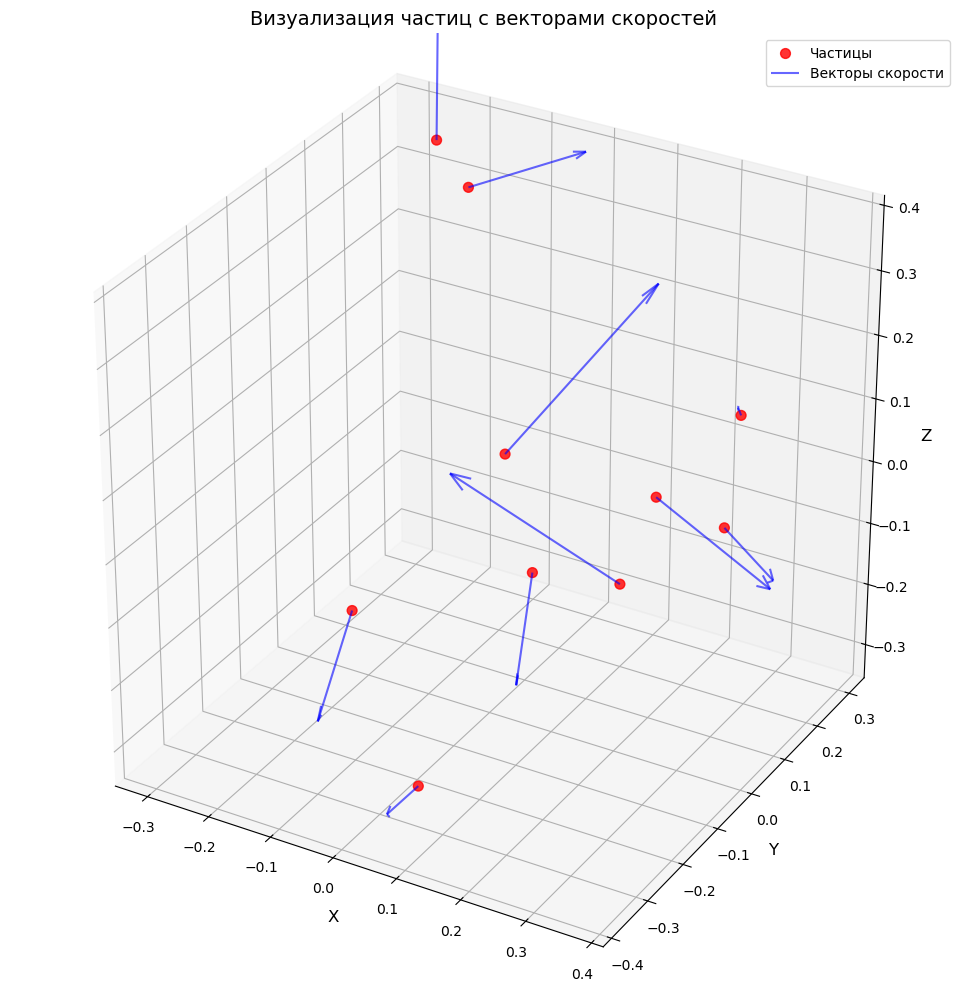

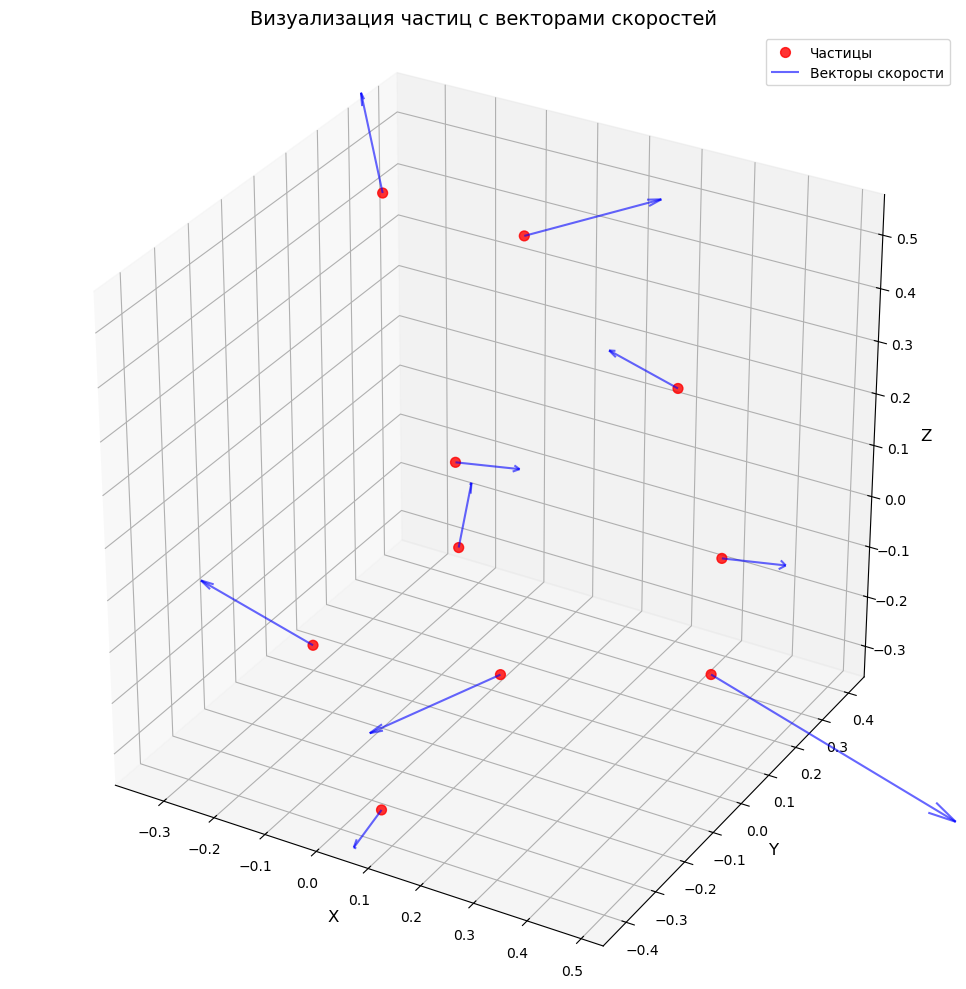

In [162]:
visualize_particles(dataset13[5][0], 0.3, 1.0, '1.jpg')
visualize_particles(dataset13[5][1], 0.3, 1.0, '2.jpg')